# Machine Learning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Classification

### Binomial

In [2]:
ads_data = pd.read_csv("Social_Network_Ads.csv")
ads_data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
ads_data.drop(columns=['User ID', 'Gender', 'EstimatedSalary'], inplace=True)
ads_data.head()

,Age,Purchased
0,19,0
1,35,0
2,26,0
3,27,0
4,19,0


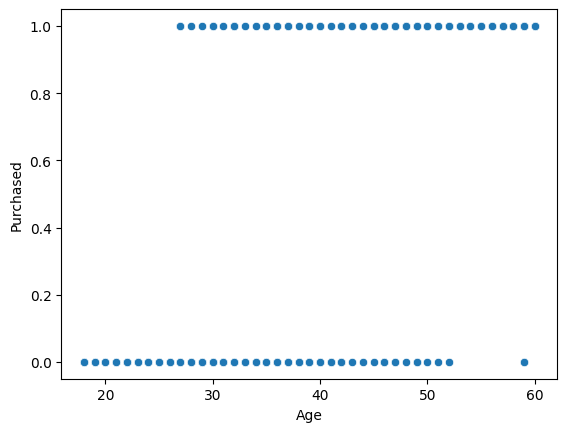

In [4]:
sns.scatterplot(x='Age', y='Purchased', data=ads_data)
plt.show()

In [5]:
x = ads_data[['Age']]
y = ads_data['Purchased']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [9]:
lr.score(x_test, y_test)

0.9125

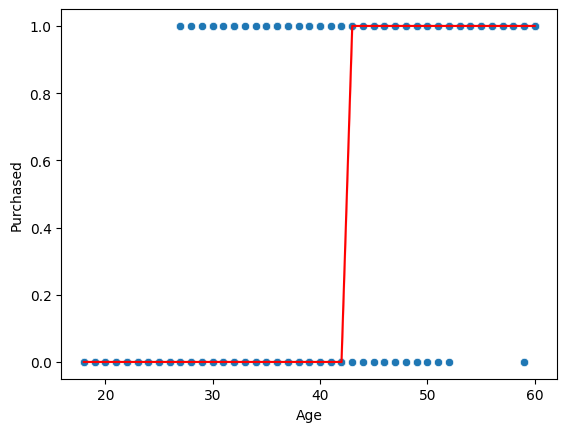

In [10]:
sns.scatterplot(x='Age', y='Purchased', data=ads_data)
sns.lineplot(x='Age', y=lr.predict(x), data=ads_data, color ="red")
plt.show()

### Multinomial

In [11]:
placement_data = pd.read_csv('Placement (1).csv')
placement_data.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [12]:
placement_data.drop(columns=['Student_ID'] ,inplace=True)

<Axes: xlabel='CGPA', ylabel='IQ'>

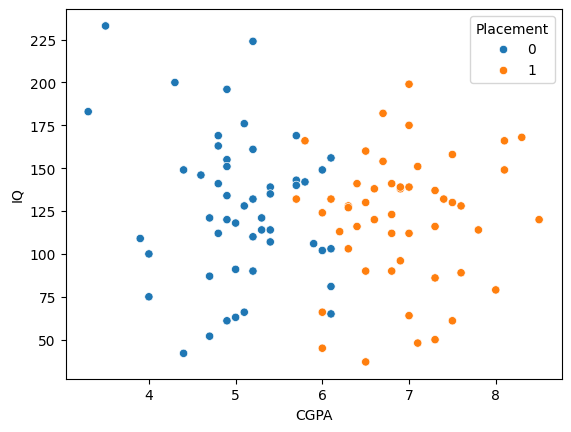

In [13]:
sns.scatterplot(x='CGPA', y='IQ', data=placement_data, hue='Placement')

In [14]:
x_p = placement_data.iloc[:, :-1]
y_p = placement_data['Placement']

In [15]:
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(x_p,y_p,test_size=0.2,random_state=42)

In [16]:
lr.fit(x_train_p, y_train_p)

LogisticRegression()

In [17]:
lr.score(x_test_p, y_test_p)

0.85

In [18]:
from mlxtend.plotting import plot_decision_regions

c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


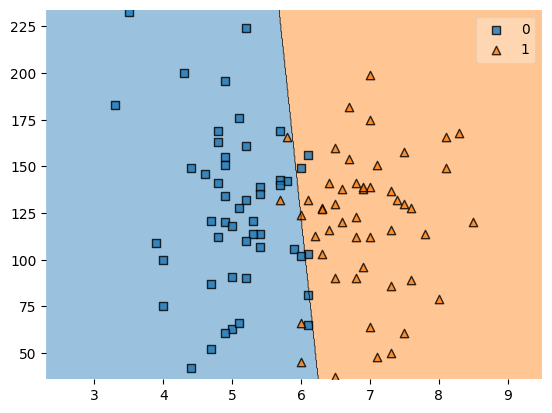

In [19]:
plot_decision_regions(x_p.to_numpy(), y_p.to_numpy(),clf=lr)
plt.show()

### Polynomial

In [20]:
# from sklearn.preprocessing import PolynomicalFeatures 
# pf = PolynomialFeatures(deg=2)
# pf.fit()

#### Multiclass

In [21]:
iris_data = pd.read_csv("iris.csv")
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [22]:
iris_data['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

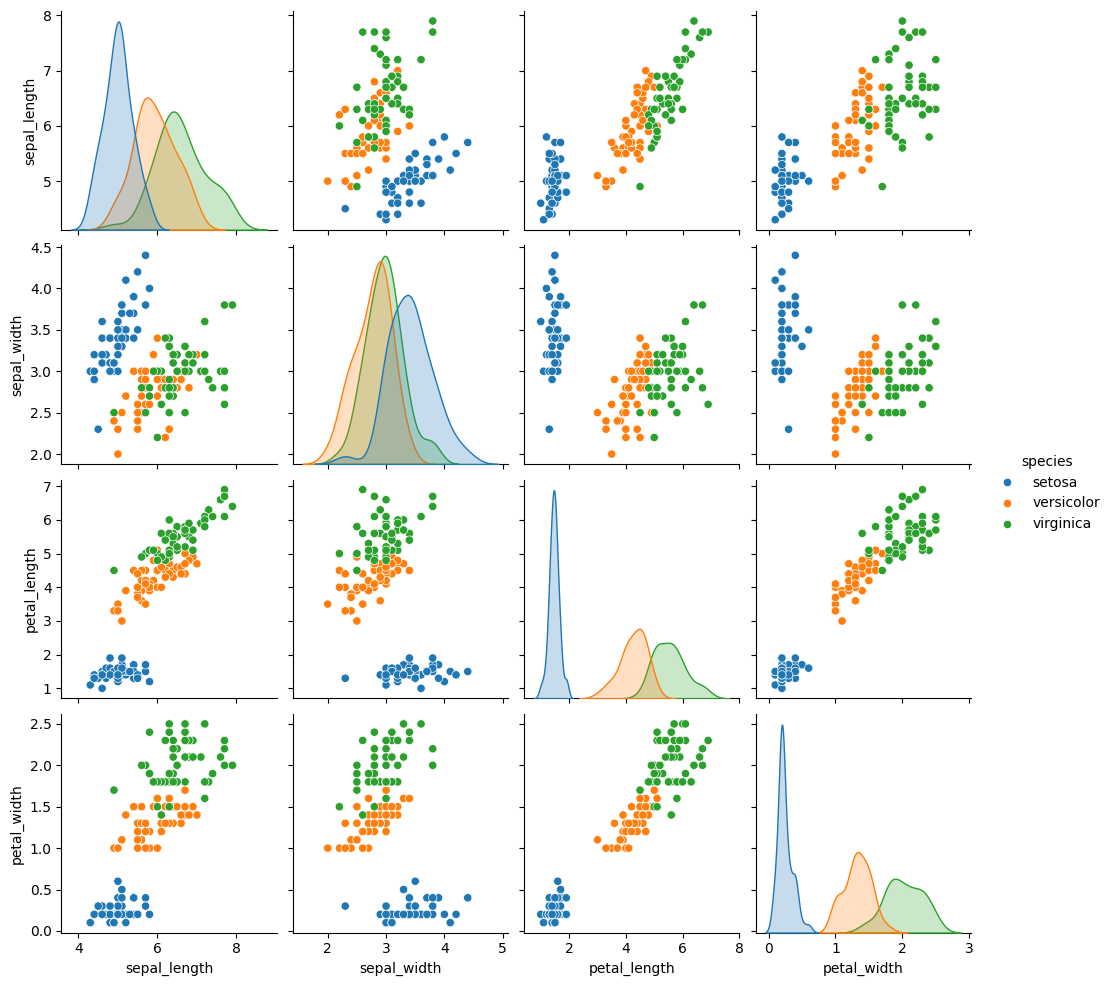

In [23]:
sns.pairplot(data=iris_data, hue='species')
plt.show()

In [24]:
x_i = iris_data.iloc[:,:-1]
y_i = iris_data['species']

In [25]:
x_train_i, x_test_i, y_train_i, y_test_i = train_test_split(x_i, y_i, random_state=42, test_size=0.2)

In [26]:
# OVR
lrovr = LogisticRegression(multi_class='ovr')
lrovr.fit(x_train_i, y_train_i)

c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [27]:
lrovr.score(x_test_i, y_test_i)

0.9666666666666667

In [28]:
# Multinomial
lrmulti = LogisticRegression(multi_class='multinomial')

In [29]:
lrmulti.fit(x_train_i, y_train_i)

c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

In [30]:
lrmulti.score(x_test_i, y_test_i)

1.0

In [31]:
lrauto = LogisticRegression()

In [32]:
lrauto.fit(x_train_i, y_train_i)

LogisticRegression()

In [33]:
lrauto.score(x_test_i, y_test_i)

1.0

## Confusion Matrix

In [34]:
# Confusion Matrix 
placement_data = pd.read_csv('placement.csv')
placement_data.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [35]:
placement_data.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [36]:
x = placement_data.iloc[:, :-1]
y = placement_data['placed']

In [37]:
x_train_place, x_test_place, y_train_place, y_test_place = train_test_split(x,y,test_size=0.2, random_state=42)

In [38]:
lr.fit(x_train_place, y_train_place)

LogisticRegression()

In [39]:
lr.score(x_test_place, y_test_place)

0.54

In [40]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [41]:
cf = confusion_matrix(y_test_place, lr.predict(x_test_place))

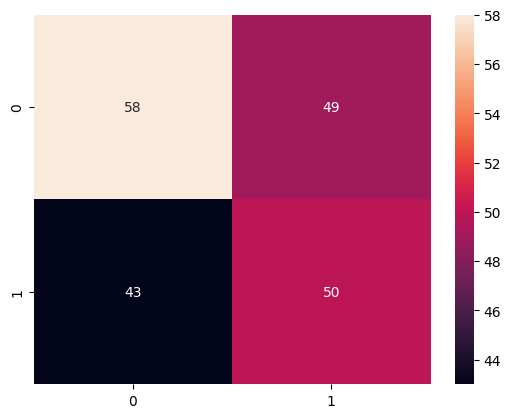

In [42]:
sns.heatmap(cf, annot=True)
plt.show()

In [43]:
precision_score(y_test_place, lr.predict(x_test_place))

0.5050505050505051

In [44]:
recall_score(y_test_place, lr.predict(x_test_place))

0.5376344086021505

In [45]:
f1_score(y_test_place, lr.predict(x_test_place))

0.5208333333333334

## Imbalanced Data

In [46]:
new_ads = pd.read_csv('Social_Network_Ads.csv')
new_ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [47]:
new_ads.drop(columns=['User ID','Gender'], inplace=True)
new_ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [48]:
new_ads['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

### Random Under Sampling

In [49]:
from imblearn.under_sampling import RandomUnderSampler

In [50]:
ru = RandomUnderSampler()

In [51]:
x = new_ads.iloc[:, :-1]
y = new_ads['Purchased']

In [52]:
ru.fit(x,y)

RandomUnderSampler()

In [53]:
ru_x, ru_y = ru.fit_resample(x,y)

In [54]:
ru_y.value_counts()

Purchased
0    143
1    143
Name: count, dtype: int64

In [55]:
x_train_ad, x_test_ad, y_train_ad, y_test_ad = train_test_split(ru_x,ru_y,test_size=0.2,random_state=42)

In [56]:
lr.fit(x_train_ad, y_train_ad)

LogisticRegression()

In [57]:
lr.score(x_test_ad, y_test_ad)

0.7413793103448276

In [58]:
# Before = 0.8875

### Random Over Sampling

In [59]:
from imblearn.over_sampling import RandomOverSampler
ro = RandomOverSampler()

In [60]:
ro_x , ro_y = ro.fit_resample(x,y)

In [61]:
x_train_ad, x_test_ad, y_train_ad, y_test_ad = train_test_split(ro_x,ro_y,test_size=0.2,random_state=42)

In [62]:
lr.fit(x_train_ad, y_train_ad)

LogisticRegression()

In [63]:
lr.score(x_test_ad, y_test_ad)

0.883495145631068

## Naive Bayes Theorem

In [64]:
placement_data.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [65]:
from mlxtend.plotting import plot_decision_regions

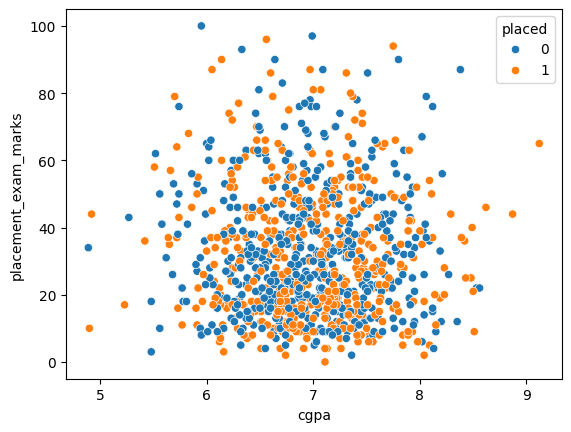

In [66]:
sns.scatterplot(x='cgpa', y='placement_exam_marks',data=placement_data, hue='placed')
plt.show()

In [67]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [68]:
gnb= GaussianNB()

In [69]:
gnb.fit(x_train_place, y_train_place)

GaussianNB()

In [70]:
gnb.score(x_test_place, y_test_place), gnb.score(x_train_place, y_train_place)

(0.53, 0.535)

In [71]:
mnb = MultinomialNB()

In [72]:
mnb.fit(x_train_place, y_train_place)

MultinomialNB()

In [73]:
mnb.score(x_test_place, y_test_place), mnb.score(x_train_place, y_train_place)

(0.535, 0.5125)

In [74]:
bnb = BernoulliNB()

In [75]:
bnb.fit(x_train_place, y_train_place)

BernoulliNB()

In [76]:
bnb.score(x_test_place, y_test_place), bnb.score(x_train_place, y_train_place)

(0.535, 0.50625)

In [77]:
# plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=gnb )

## Decision Tree

### Classification

In [78]:
new_ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [79]:
new_ads.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [80]:
x = new_ads.iloc[:,:-1]
y = new_ads['Purchased']

In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
ss = StandardScaler()

In [83]:
ss.fit(x)

StandardScaler()

In [84]:
x = pd.DataFrame(ss.transform(x), columns=x.columns)

In [85]:
x.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [86]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=2)

In [89]:
dt.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

In [90]:
dt.score(x_test, y_test)

0.9125

In [91]:
dt.score(x_train, y_train)

0.91875

In [92]:
from sklearn.tree import plot_tree

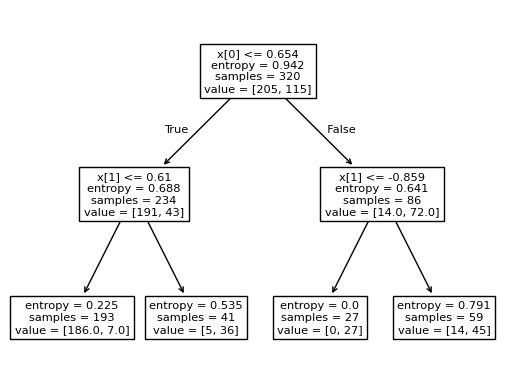

In [93]:
plot_tree(dt)
plt.show()

In [94]:
for i in range(1,20):
    dt1 = DecisionTreeClassifier(max_depth=i)
    dt1.fit(x_train, y_train)
    print("score", i , "=", dt1.score(x_test, y_test),",", dt1.score(x_train, y_train))

score 1 = 0.9 , 0.821875
score 2 = 0.9125 , 0.91875
score 3 = 0.9125 , 0.91875
score 4 = 0.9125 , 0.93125
score 5 = 0.9 , 0.934375
score 6 = 0.8625 , 0.95
score 7 = 0.85 , 0.96875
score 8 = 0.85 , 0.971875
score 9 = 0.85 , 0.98125
score 10 = 0.85 , 0.984375
score 11 = 0.8375 , 0.990625
score 12 = 0.8375 , 0.99375
score 13 = 0.8375 , 0.996875
score 14 = 0.8375 , 0.996875
score 15 = 0.8375 , 0.996875
score 16 = 0.8375 , 0.996875
score 17 = 0.8375 , 0.996875
score 18 = 0.8375 , 0.996875
score 19 = 0.8375 , 0.996875


c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<Axes: >

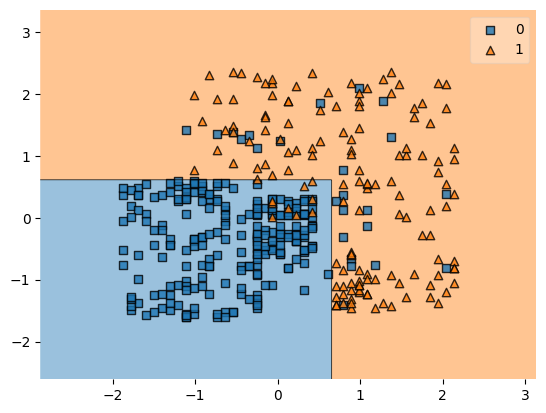

In [95]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf=dt)

### Regression

In [96]:
from sklearn.tree import DecisionTreeRegressor

In [97]:
dtr = DecisionTreeRegressor()

## KNN 

### Classifier

In [98]:
new_ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


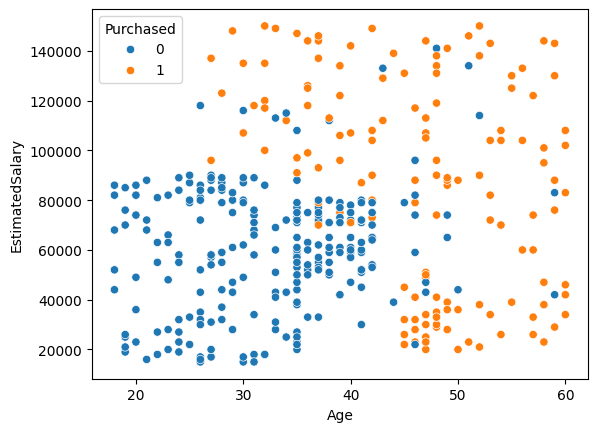

In [99]:
sns.scatterplot(x='Age', y='EstimatedSalary', data=new_ads, hue='Purchased')
plt.show()

In [100]:
x = new_ads.iloc[:, :-1]
y = new_ads['Purchased']

In [101]:
ss.fit(x)

StandardScaler()

In [102]:
x = pd.DataFrame(ss.transform(x), columns=x.columns)

In [103]:
x.head()

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [104]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn = KNeighborsClassifier(n_neighbors=3)

In [107]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [108]:
knn.score(x_test, y_test)

0.9125

In [109]:
knn.score(x_train, y_train)

0.925

In [110]:
for i in range(1,30):
    knn1 = KNeighborsClassifier(n_neighbors=i)
    knn1.fit(x_train, y_train)
    print('(train, test) score: ',i,knn1.score(x_train, y_train), knn1.score(x_test, y_test))

(train, test) score:  1 0.996875 0.85
(train, test) score:  2 0.915625 0.8625
(train, test) score:  3 0.925 0.9125
(train, test) score:  4 0.91875 0.925
(train, test) score:  5 0.909375 0.925
(train, test) score:  6 0.909375 0.9
(train, test) score:  7 0.91875 0.9375
(train, test) score:  8 0.90625 0.925
(train, test) score:  9 0.9125 0.9375
(train, test) score:  10 0.90625 0.925
(train, test) score:  11 0.909375 0.925
(train, test) score:  12 0.9125 0.925
(train, test) score:  13 0.915625 0.925
(train, test) score:  14 0.90625 0.925
(train, test) score:  15 0.90625 0.925
(train, test) score:  16 0.9 0.925
(train, test) score:  17 0.90625 0.925
(train, test) score:  18 0.9 0.925
(train, test) score:  19 0.909375 0.925
(train, test) score:  20 0.9 0.9375
(train, test) score:  21 0.903125 0.925
(train, test) score:  22 0.9 0.9375
(train, test) score:  23 0.903125 0.9375
(train, test) score:  24 0.89375 0.9375
(train, test) score:  25 0.9 0.9375
(train, test) score:  26 0.89375 0.9375
(tr

c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


<Axes: >

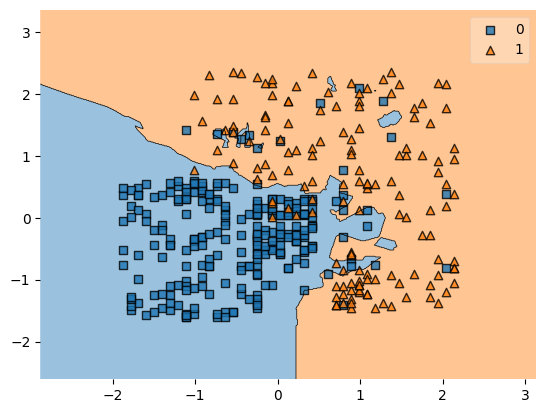

In [111]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)

### Regression

In [112]:
from sklearn.neighbors import KNeighborsRegressor

In [113]:
knnr = KNeighborsRegressor()

## SVM

### Classifier

In [114]:
from sklearn.svm import SVC

In [115]:
svc = SVC(kernel="linear")

### Regression

In [116]:
dataset = pd.read_csv('package.csv')
dataset.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


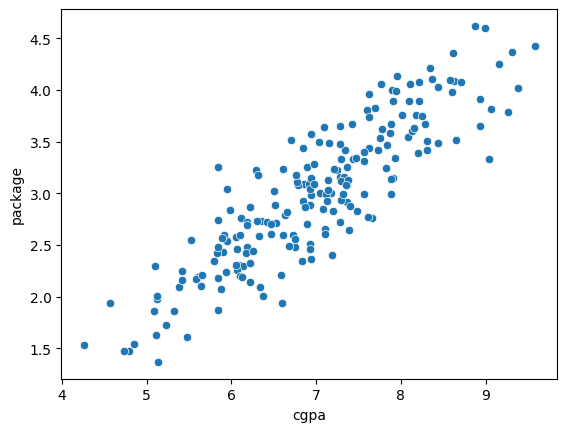

In [117]:
sns.scatterplot(x='cgpa', y='package', data=dataset)
plt.show()

In [118]:
x = dataset.iloc[:,:-1]
y = dataset['package']

In [119]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [120]:
from sklearn.svm import SVR

In [121]:
svr = SVR(kernel="linear")

In [122]:
svr.fit(x_train, y_train)

SVR(kernel='linear')

In [123]:
svr.score(x_test, y_test)

0.7706668029575103

In [124]:
svr.score(x_train, y_train)

0.7745351616879739

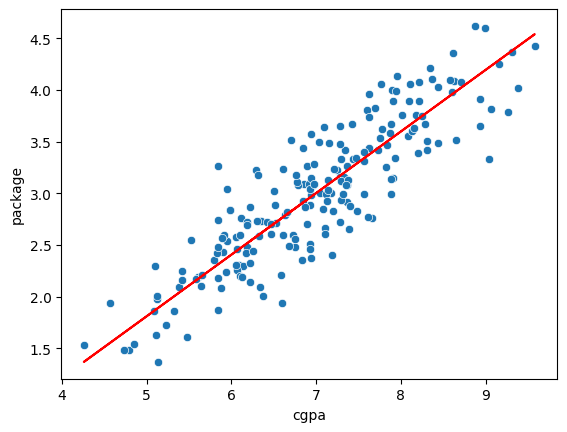

In [125]:
sns.scatterplot(x='cgpa', y='package', data=dataset)
plt.plot(dataset['cgpa'], svr.predict(x), color="red")
plt.show()

## Hyperparameter Tuning

In [126]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [127]:
''' df = {'criterion': ["squared_error", "friedman_mse", "absolute_error", "poisson"],
      'splitter': ["best", "random"],
      'max_depth': [i for i in range(1,20)]
     }'''

' df = {\'criterion\': ["squared_error", "friedman_mse", "absolute_error", "poisson"],\n      \'splitter\': ["best", "random"],\n      \'max_depth\': [i for i in range(1,20)]\n     }'

In [128]:
# gcv = GridSearchCV(DecisionTreeRegressor(), param_grid=df)

In [129]:
# rcv = RandomizedSearchCV(DecisionTreeRegressor(), param_distributions=df, n_iter=20)

In [130]:
# gcv.best_params_, gcv.best_score_

## Cross Validation

In [131]:
new_data = dataset.head(10)

In [132]:
new_x = new_data.iloc[:,:-1]
new_y = new_data['package']

In [133]:
from sklearn.model_selection import LeaveOneOut, LeavePOut, KFold, StratifiedKFold

In [134]:
'''lo = StratifiedKFold(n_splits=5)

for train , test, in lo.split(new_x,new_y):
    print(train,test) '''

'lo = StratifiedKFold(n_splits=5)\n\nfor train , test, in lo.split(new_x,new_y):\n    print(train,test) '

In [135]:
from sklearn.model_selection import cross_val_score

In [136]:
'''p = cross_val_score(LogisticRegression(), x, y, cv=KFold(n_splits=10))
p.sort()
print(p*100)'''

'p = cross_val_score(LogisticRegression(), x, y, cv=KFold(n_splits=10))\np.sort()\nprint(p*100)'

## Unsupervised Learning

### K Means Clustering

In [137]:
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [138]:
iris_data.drop(columns=['species'], inplace=True)

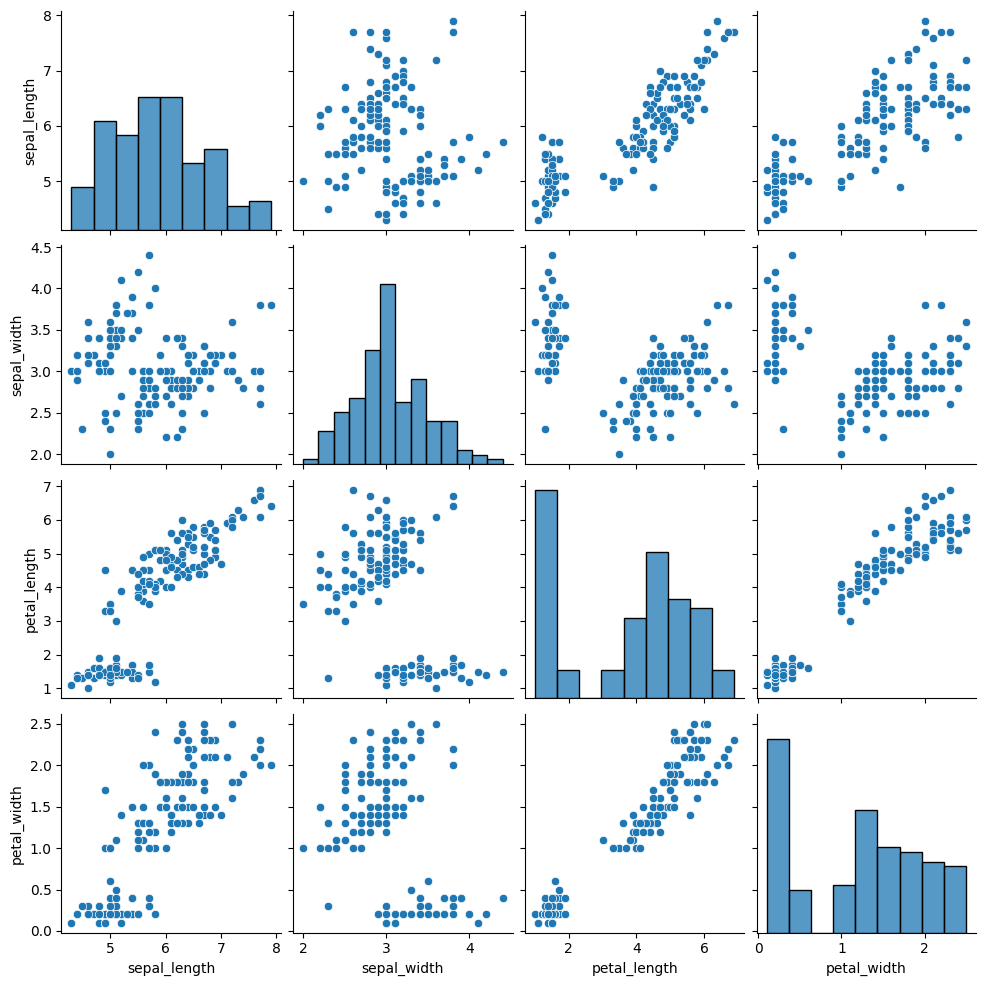

In [139]:
sns.pairplot(data=iris_data)
plt.show()

In [140]:
from sklearn.cluster import KMeans

In [141]:
wcss = []

for i in range (2,21):
    km = KMeans(n_clusters=i, init='k-means++')
    km.fit(iris_data)
    wcss.append(km.inertia_)

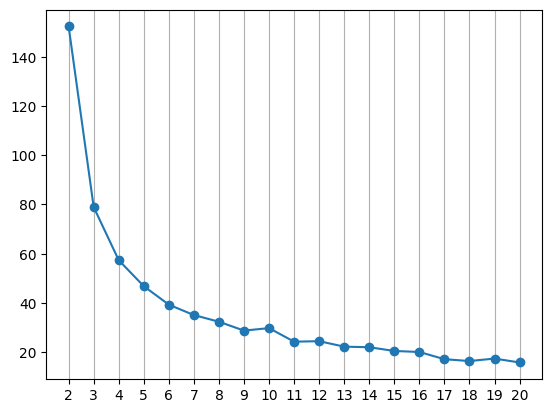

In [142]:
plt.plot([i for i in range(2,21)], wcss, marker="o")
plt.xticks([i for i in range(2,21)])
plt.grid(axis='x')
plt.show()

In [143]:
kmn = KMeans(n_clusters=3)
iris_data["Predict"]= kmn.fit_predict(iris_data)

### Silhouette Score

In [144]:
from sklearn.metrics import silhouette_score

In [145]:
kmn.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [146]:
silhouette_score(iris_data, labels=kmn.labels_)

np.float64(0.684936462996038)

In [147]:
ss = []
no_c = [j for j in range(2,21)]
for i in range (2,21):
    km1 = KMeans(n_clusters=i)
    km1.fit(iris_data)
    ss.append(silhouette_score(iris_data, km1.labels_))

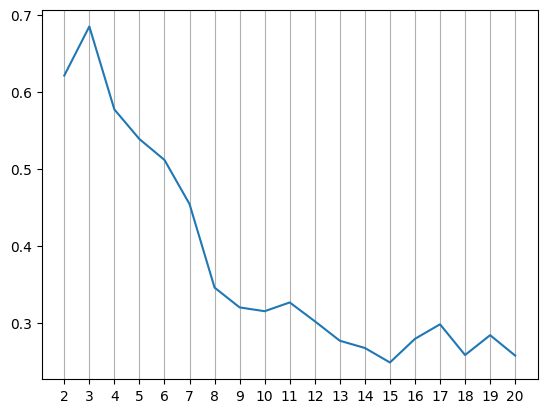

In [148]:
plt.plot(no_c, ss)
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()

In [149]:
iris_data['predict'] = kmn.fit_predict(iris_data)

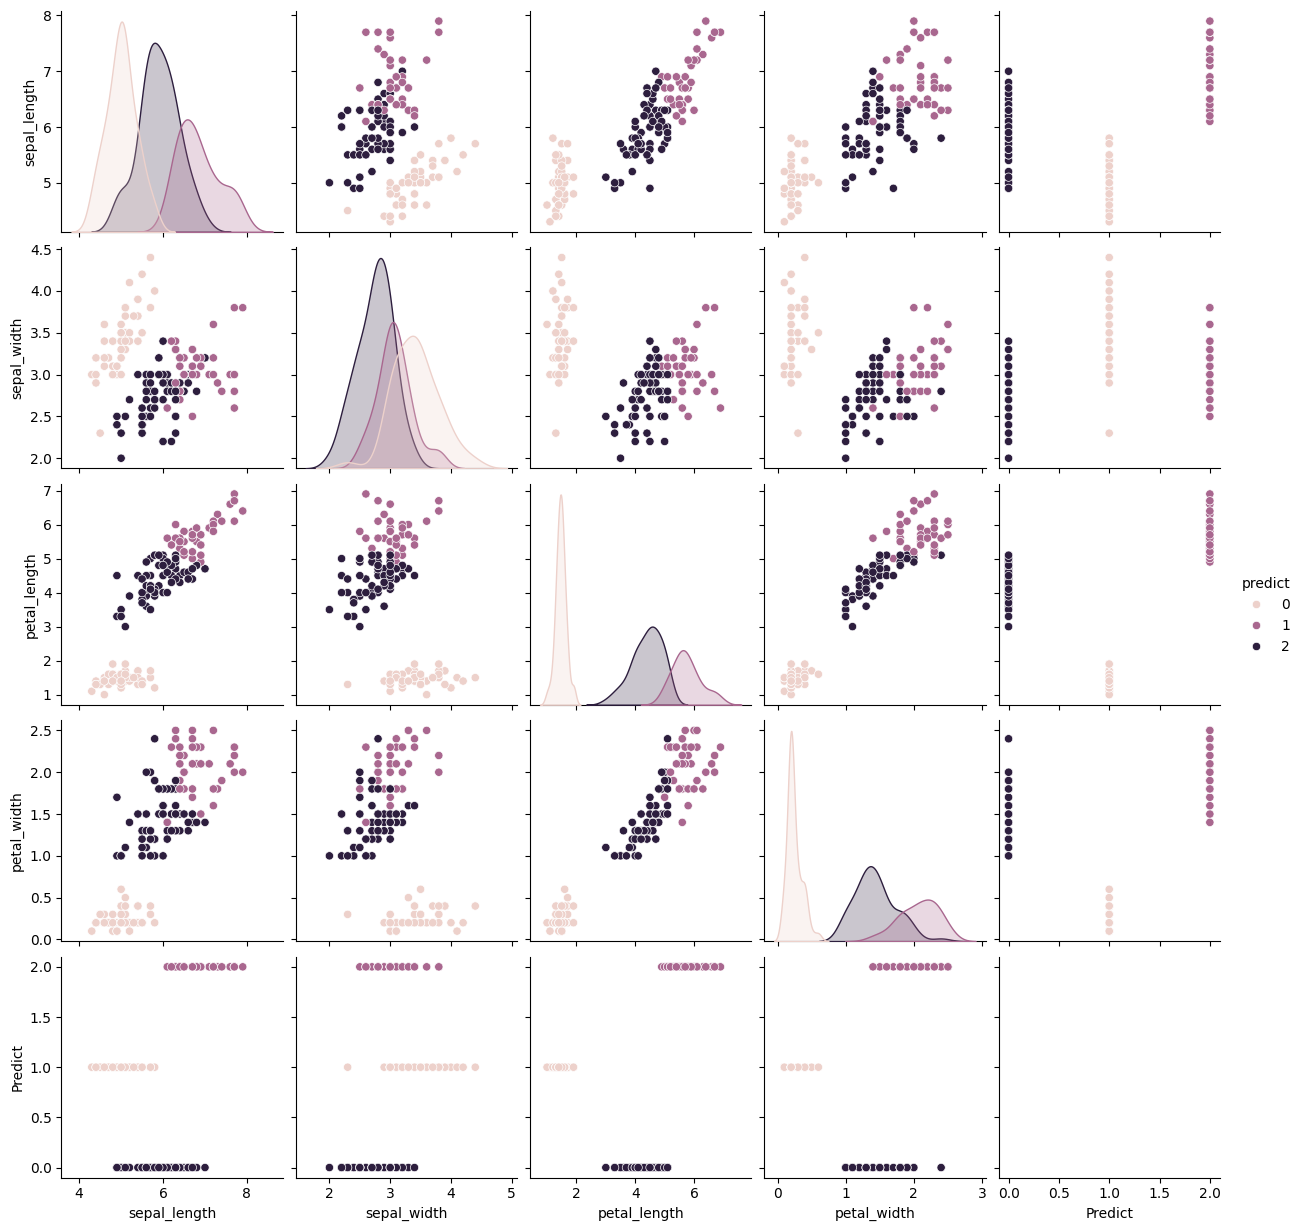

In [150]:
sns.pairplot(data=iris_data, hue="predict")

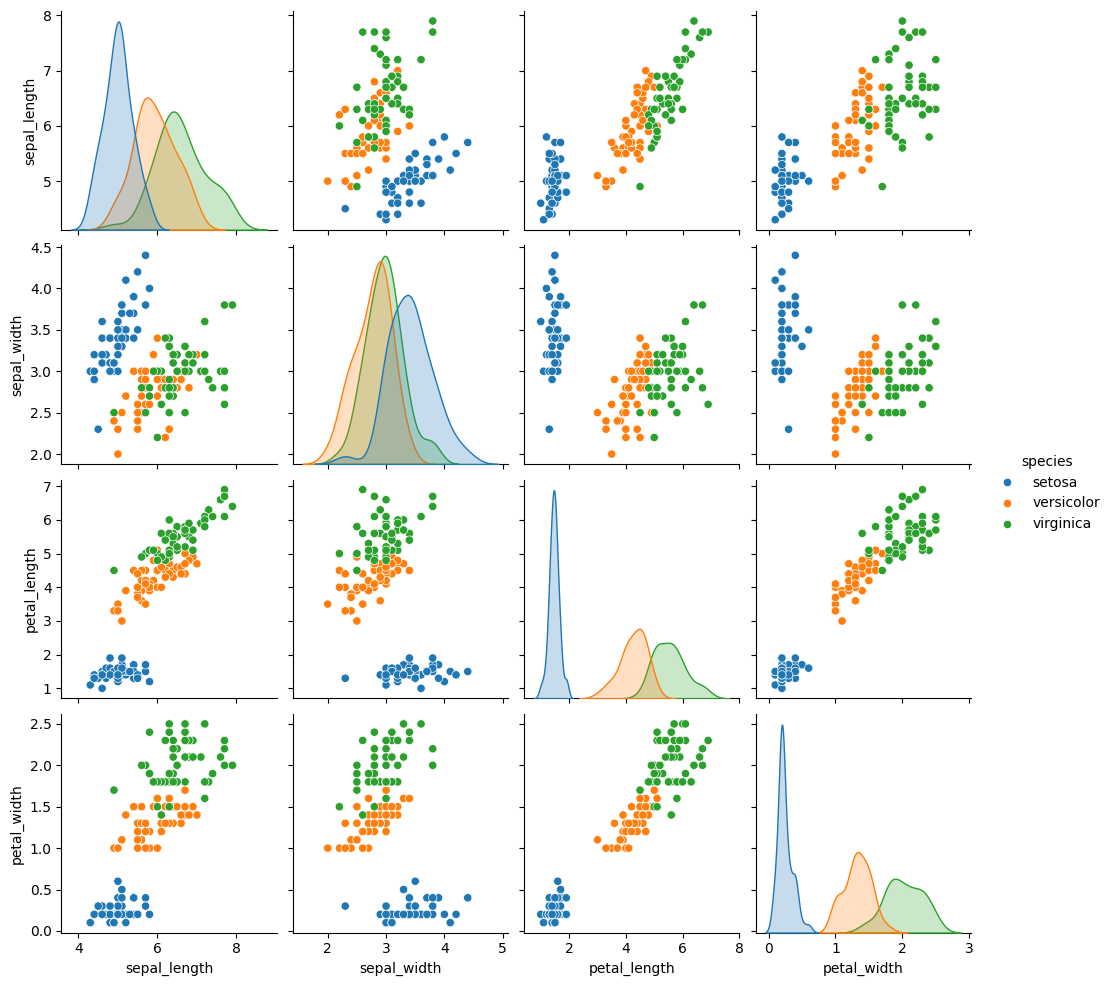

In [151]:
org_data = pd.read_csv('iris.csv')
sns.pairplot(data=org_data, hue='species')
plt.show()

### Hiearchial Clustering

#### Agglomerative

In [152]:
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,Predict,predict
0,5.1,3.5,1.4,0.2,1,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,1,0


In [153]:
iris_data.drop(columns=['predict'], inplace=True)

In [154]:
import scipy.cluster.hierarchy as sc

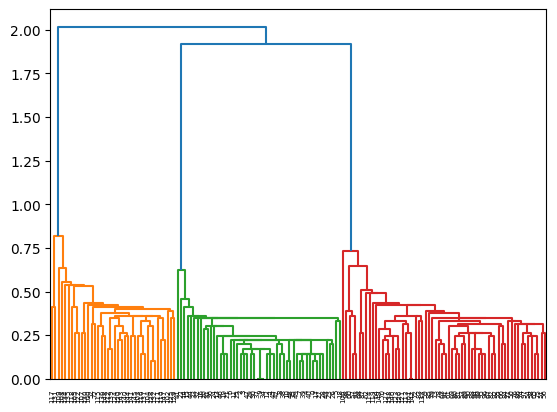

In [155]:
sc.dendrogram(sc.linkage(iris_data, method='single', metric='euclidean'))
plt.show()

In [156]:
from sklearn.cluster import AgglomerativeClustering

In [157]:
ac = AgglomerativeClustering(n_clusters=2, linkage='single')

In [158]:
iris_data['predict'] = ac.fit_predict(iris_data)

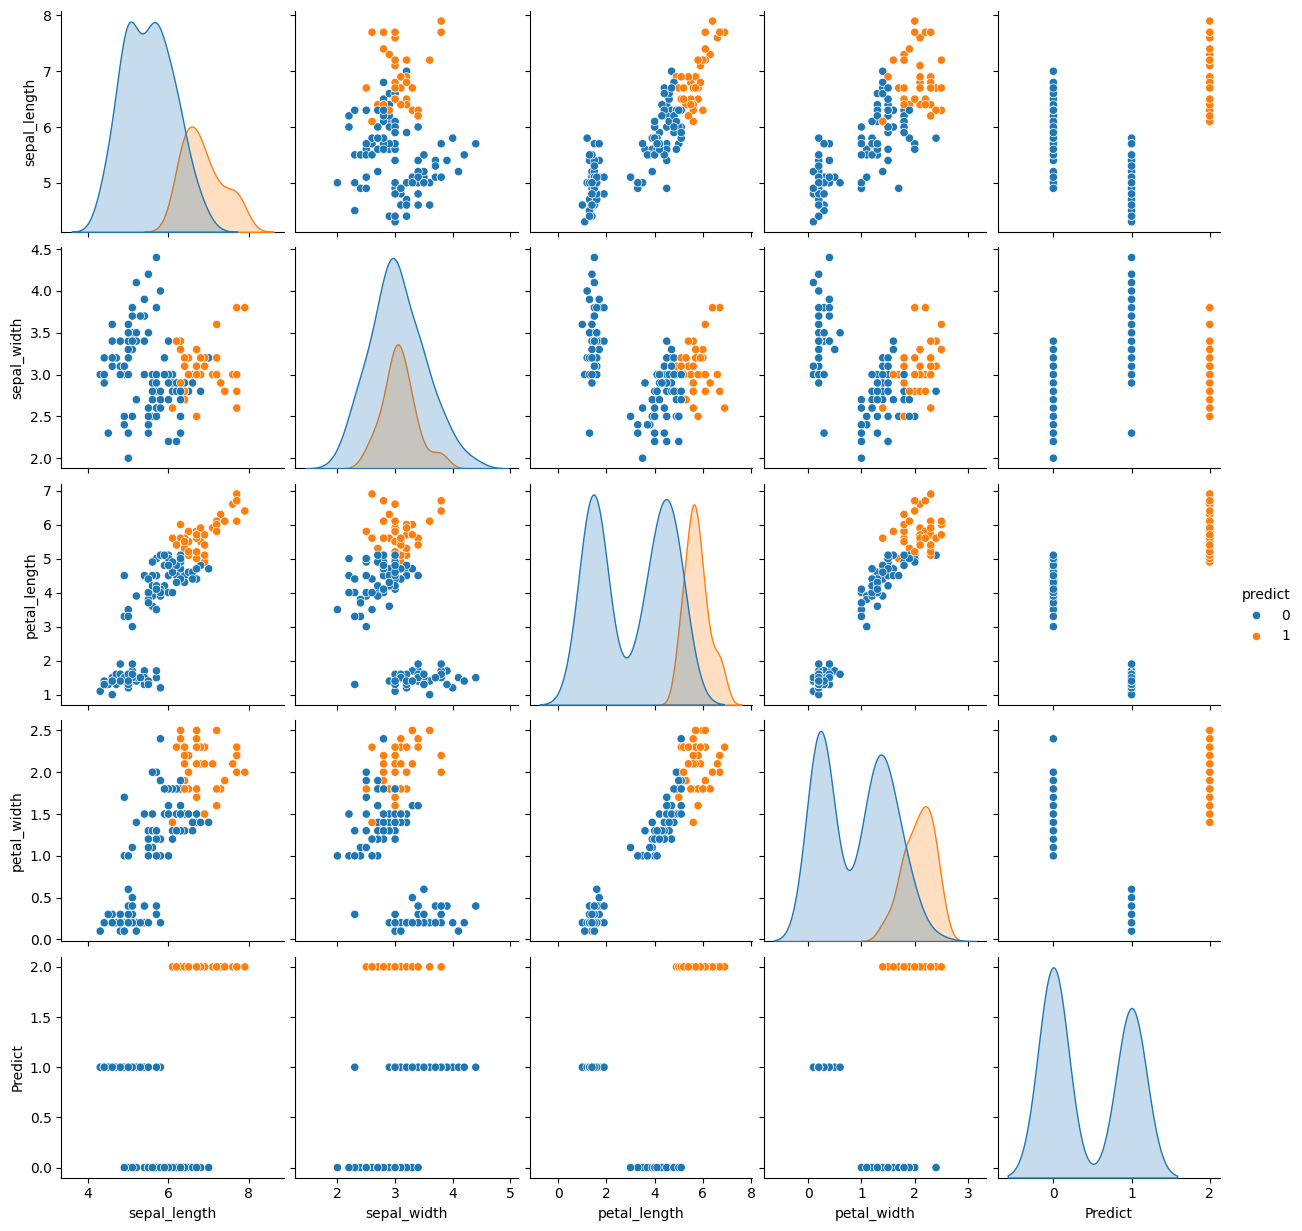

In [159]:
sns.pairplot(iris_data, hue='predict')

### DBSCAN Clustering

In [160]:
from sklearn.datasets import make_moons

In [161]:
x, y = make_moons(n_samples=250, noise=0.05)

In [162]:
df = {"data1": x[:,0], "data2": x[:,1]}

In [163]:
dataset = pd.DataFrame(df)

In [164]:
dataset.head()

,data1,data2
0,-0.197970,0.984606
1,-0.652026,0.883327
2,1.537164,-0.317041
3,0.609488,-0.327551
4,0.312893,0.977317


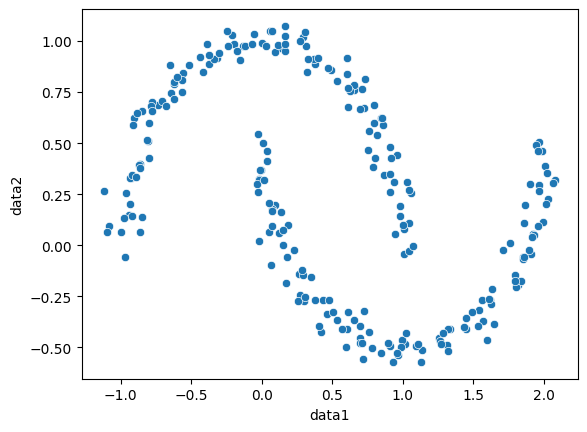

In [165]:
sns.scatterplot(x="data1", y="data2", data=dataset)
plt.show()

In [166]:
from sklearn.cluster import DBSCAN

In [167]:
db = DBSCAN(eps=0.2, min_samples=5)

In [168]:
dataset['predict'] = db.fit_predict(dataset)

<Axes: xlabel='data1', ylabel='data2'>

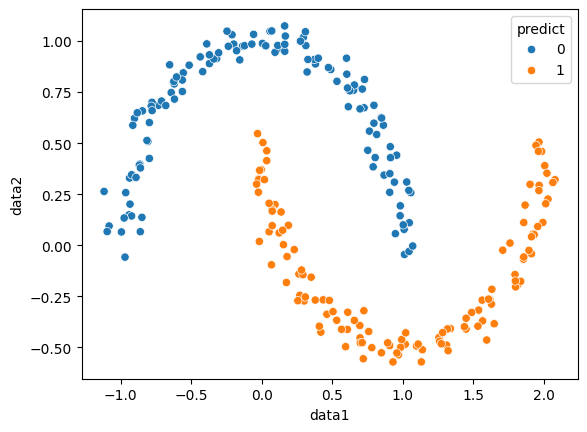

In [169]:
sns.scatterplot(x='data1', y='data2', data=dataset, hue=dataset['predict'])

<Axes: xlabel='data1', ylabel='data2'>

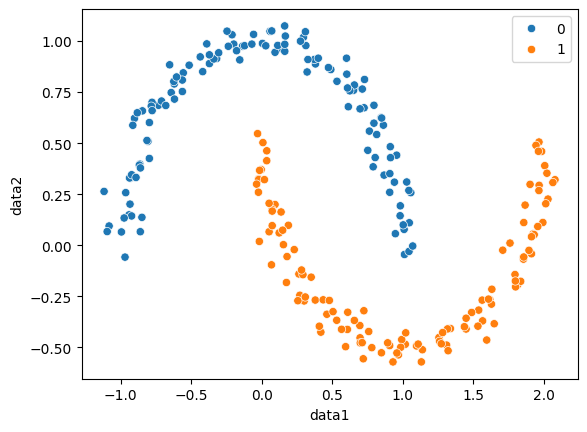

In [170]:
sns.scatterplot(x='data1', y='data2', data=dataset, hue=y)

### Association

#### Apriori

In [171]:
grocery_data = pd.read_csv('Grocery Products Purchase.csv')

In [172]:
grocery_data.head()

,Product 1,Product 2,Product 3,Product 4,Product 5,Product 6,Product 7,Product 8,Product 9,Product 10,...,Product 23,Product 24,Product 25,Product 26,Product 27,Product 28,Product 29,Product 30,Product 31,Product 32
0,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
grocery_data.shape

(9835, 32)

In [174]:
market = []
for i in range (0, grocery_data.shape[0]):
    cus = []
    for j in grocery_data.columns :
        if type(grocery_data[j][i]) == str:
            cus.append(grocery_data[j][i])
        market.append(cus)

In [175]:
import collections 

In [176]:
l = []
for i in market:
    for j in i:
        l.append(j)

In [177]:
p = collections.Counter(l)

In [178]:
p.keys()

dict_keys(['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups', 'tropical fruit', 'yogurt', 'coffee', 'whole milk', 'pip fruit', 'cream cheese', 'meat spreads', 'other vegetables', 'condensed milk', 'long life bakery product', 'butter', 'rice', 'abrasive cleaner', 'rolls/buns', 'UHT-milk', 'bottled beer', 'liquor (appetizer)', 'potted plants', 'cereals', 'white bread', 'bottled water', 'chocolate', 'curd', 'flour', 'dishes', 'beef', 'frankfurter', 'soda', 'chicken', 'sugar', 'fruit/vegetable juice', 'newspapers', 'packaged fruit/vegetables', 'specialty bar', 'butter milk', 'pastry', 'processed cheese', 'detergent', 'root vegetables', 'frozen dessert', 'sweet spreads', 'salty snack', 'waffles', 'candy', 'bathroom cleaner', 'canned beer', 'sausage', 'brown bread', 'shopping bags', 'beverages', 'hamburger meat', 'spices', 'hygiene articles', 'napkins', 'pork', 'berries', 'whipped/sour cream', 'artif. sweetener', 'grapes', 'dessert', 'zwieback', 'domestic eggs', 'spread chees

In [179]:
p.values()

dict_values([26048, 5568, 18432, 576, 33024, 43904, 18272, 80416, 23808, 12480, 1344, 60896, 3232, 11776, 17440, 2400, 1120, 57888, 10528, 25344, 2496, 5440, 1792, 13248, 34784, 15616, 16768, 5472, 5536, 16512, 18560, 54880, 13504, 10656, 22752, 25120, 4096, 8608, 8800, 28000, 5216, 6048, 34304, 3392, 2848, 11904, 12096, 9408, 864, 24448, 29568, 20416, 31008, 8192, 10464, 1632, 10368, 16480, 18144, 10464, 22560, 1024, 7040, 11680, 2176, 19968, 3520, 8928, 7712, 7328, 8192, 2560, 5568, 5632, 8832, 6624, 2848, 7872, 15136, 4736, 4480, 1600, 6048, 2656, 1152, 9568, 2816, 3264, 1760, 3392, 8928, 3392, 9760, 5120, 5984, 1312, 2912, 7712, 4736, 1728, 3584, 928, 1440, 1024, 2528, 5376, 480, 1824, 2272, 4160, 960, 608, 2688, 2048, 704, 2688, 640, 3680, 256, 1600, 1920, 3296, 864, 8128, 1216, 3776, 2624, 1120, 896, 3488, 2976, 2144, 1408, 256, 1728, 2048, 832, 352, 2336, 3232, 2880, 320, 1024, 1600, 192, 512, 992, 1888, 192, 1312, 1344, 1696, 480, 1056, 288, 704, 416, 224, 544, 32, 736, 736, 25

In [180]:
d = {"item name": p.keys(), "values": p.values()}

In [181]:
# pd.set_option("display.max_rows", 200)

In [182]:
pd.DataFrame(d).sort_values(by=["values"], ascending=False)

,item name,values
7,whole milk,80416
11,other vegetables,60896
17,rolls/buns,57888
31,soda,54880
5,yogurt,43904
...,...,...
164,bags,128
167,kitchen utensil,128
168,preservation products,64
159,baby food,32


In [183]:
from mlxtend.preprocessing.transactionencoder import TransactionEncoder

In [184]:
tr = TransactionEncoder()

In [185]:
tr.fit(market)

TransactionEncoder()

In [186]:
df = pd.DataFrame(tr.transform(market), columns=tr.columns_)

In [187]:
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [188]:
from mlxtend.frequent_patterns import apriori

In [189]:
apriori(df, min_support=0.05, use_colnames=True, max_len=3).sort_values(by=['support'])

,support,itemsets
13,0.052364,(napkins)
0,0.052466,(beef)
8,0.053279,(curd)
4,0.055414,(butter)
30,0.056024,"(whole milk, yogurt)"
29,0.056634,"(rolls/buns, whole milk)"
18,0.057651,(pork)
7,0.058058,(coffee)
12,0.058566,(margarine)
10,0.058973,(frankfurter)


#### FP Growth

In [190]:
from mlxtend.frequent_patterns import fpgrowth

In [191]:
fpgrowth(df, min_support=0.05, max_len=3, use_colnames=True).sort_values(by=['support'])

,support,itemsets
24,0.052364,(napkins)
13,0.052466,(beef)
12,0.053279,(curd)
8,0.055414,(butter)
28,0.056024,"(whole milk, yogurt)"
30,0.056634,"(rolls/buns, whole milk)"
26,0.057651,(pork)
4,0.058058,(coffee)
1,0.058566,(margarine)
15,0.058973,(frankfurter)


### Ensemble Learning

In [192]:
x, y = make_moons(n_samples=1000, noise=0.2)

In [193]:
df = {"x1": x[:,0], "x2": x[:,1], "y": y}

In [194]:
dataset = pd.DataFrame(df)

<Axes: xlabel='x1', ylabel='x2'>

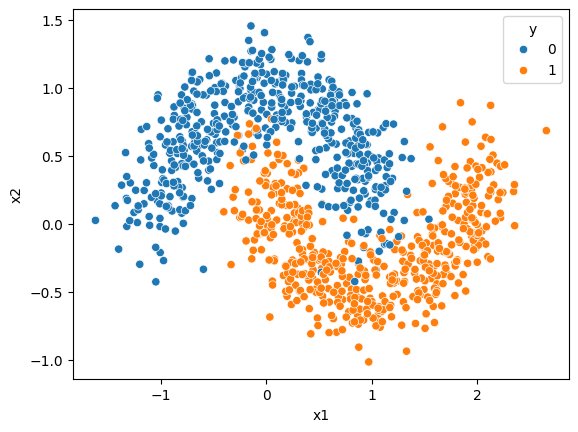

In [195]:
sns.scatterplot(x="x1", y="x2", data=dataset, hue="y")

In [196]:
x_a  = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [197]:
x_train, x_test, y_train, y_test = train_test_split(x_a, y_a, test_size=0.2, random_state=42)

In [198]:
dt.fit(x_train, y_train)
dt.score(x_train, y_train), dt.score(x_test, y_test)

(0.92, 0.925)

In [199]:
svc.fit(x_train, y_train)
svc.score(x_train, y_train), svc.score(x_test, y_test)

(0.87, 0.89)

In [200]:
gnb.fit(x_train, y_train)
gnb.score(x_train, y_train), gnb.score(x_test, y_test)

(0.86375, 0.89)

#### Voting

In [201]:
# Classifier
from sklearn.ensemble import VotingClassifier

In [202]:
l = [("dt1",DecisionTreeClassifier()), ("svc1", SVC()), ("gnb1", GaussianNB())]

In [203]:
vc = VotingClassifier(l)

In [204]:
vc.fit(x_train, y_train)

VotingClassifier(estimators=[('dt1', DecisionTreeClassifier()), ('svc1', SVC()),
                             ('gnb1', GaussianNB())])

In [205]:
vc.score(x_train, y_train), vc.score(x_test, y_test)

(0.96875, 0.955)

In [206]:
prd = {"dt": dt.predict(x_test), "svc": svc.predict(x_test), "gnb": gnb.predict(x_test), "vc": vc.predict(x_test)}

In [207]:
pd.DataFrame(prd)

,dt,svc,gnb,vc
0,0,0,0,0
1,0,0,0,1
2,1,1,1,1
3,0,0,0,0
4,0,0,0,0
...,...,...,...,...
195,0,1,1,0
196,1,1,1,1
197,1,1,1,1
198,1,1,1,1


In [208]:
dataset = pd.read_csv('package.csv')

In [209]:
dataset.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [210]:
x = dataset.iloc[:, :-1]
y = dataset['package']

In [211]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [212]:
# Regressor
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression

In [213]:
l = [("dt",DecisionTreeRegressor()), ("lr", LinearRegression()), ("svr", SVR())]

In [214]:
vr = VotingRegressor(l)

In [215]:
vr.fit(x_train, y_train)

VotingRegressor(estimators=[('dt', DecisionTreeRegressor()),
                            ('lr', LinearRegression()), ('svr', SVR())])

In [216]:
vr.score(x_train, y_train) ,vr.score(x_test, y_test)

(0.8756852979319457, 0.7516568331690885)

#### Bagging

In [217]:
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor

In [218]:
br = BaggingRegressor(estimator=LinearRegression(), n_estimators=50)

In [219]:
br.fit(x_train, y_train)

BaggingRegressor(estimator=LinearRegression(), n_estimators=50)

In [220]:
br.score(x_train, y_train), br.score(x_test, y_test)

(0.7758337398396373, 0.7730440299979975)

In [221]:
rfr =  RandomForestRegressor(n_estimators=10)

In [222]:
rfr.fit(x_train, y_train)

RandomForestRegressor(n_estimators=10)

In [223]:
rfr.score(x_train, y_train), rfr.score(x_test, y_test)

(0.9076028939448297, 0.5883161041514469)

In [224]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

In [225]:
x, y = make_moons(n_samples=1000, noise=0.2)

In [226]:
df = {"x1": x[:,0], "x2": x[:,1], "y": y}

In [227]:
dataset = pd.DataFrame(df)

In [228]:
x_a  = dataset.iloc[:,:-1]
y_a = dataset["y"]

In [229]:
x_train, x_test, y_train, y_test = train_test_split(x_a, y_a, test_size=0.2, random_state=42)

In [230]:
bc = BaggingClassifier(estimator=SVC(), n_estimators=50)

In [231]:
bc.fit(x_train, y_train)

BaggingClassifier(estimator=SVC(), n_estimators=50)

In [232]:
bc.score(x_train, y_train), bc.score(x_test, y_test)

(0.97875, 0.955)

In [233]:
rf = RandomForestClassifier(n_estimators=50)

In [234]:
rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=50)

In [235]:
rf.score(x_train, y_train), rf.score(x_test, y_test)

(1.0, 0.935)